# Final Project
## Machine Learning for Neuroscience
### Gaia Negev and Tzlil Tabib

In [ ]:
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import ast
from collections import Counter
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Initial data handling
loading, organizing and dividing to train and test

In [ ]:
# # load data from json
# with open('data/emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as f:
#     data = json.load(f)

# # data to pd.DataFrame
# df = pd.DataFrame(data)
# df_annotations = pd.DataFrame(df['annotations'].tolist())
# df = pd.concat([df.drop('annotations', axis=1), df_annotations], axis=1)
# df.head()

# # remove image_name column because it's duplicated in image_id
# df = df.drop('image_name', axis=1)
# # make image_id the index
# df = df.set_index('image_id')
# df.head()

# # divide data to train and test
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

# # save division to csv
# train_df.to_csv('data/train.csv')
# test_df.to_csv('data/test.csv')

In [2]:
# load the data 
train_df = pd.read_csv('data/train.csv', index_col='image_id')
test_df = pd.read_csv('data/test.csv', index_col='image_id')

# EDA

In [ ]:
train_df.info()

# null analysis
train_df.isnull().sum()

### Plan 
division of variables by type 
numeric - brightness, colorfulness 
category - facial expression, emotion
text - description, viewer_feelings, object, human_action, scene

Process: 
1. numeric - standarize
2. category - binary coding
3. tfidf for text variables 
4. dimension reduction to all metadata
5. insert to a model description, feelings and metadata 
    a. model selection 
    b. regularization
    c. interpretation

In [ ]:
# print how many unique values are in each column
for column in train_df.columns:
    unique_values = train_df[column].nunique()
    print(f'{column}: {unique_values} unique values')

In [ ]:
# emotion distribution to see if there is a class imbalance
emotion_counts = train_df['emotion'].value_counts()
print(emotion_counts)
emotion_counts.plot(kind='bar')

Brightness and colorfulness have a very low percentage of missing values, so we'll consider removing them depending on the model (the model's ability to work with missing values).

In [ ]:
# TODO: decide how to handle missing values in the metadata columns

## Metadata Analysis:

In [ ]:
def analyze_column(df, col_name, target_col='emotion'):
    """
    Performs a distribution analysis, null check, and correlation 
    with a target column for a specific feature.
    """
    print(f"\n{'='*10} Analyzing Column: {col_name} {'='*10}")
    
    # 0. fill 'missing' in null values for better visualization
    df[col_name] = df[col_name].fillna('missing')
    
    # 1. Distribution of the column
    plt.figure(figsize=(8, 4))
    df[col_name].value_counts().plot(kind='bar')
    plt.title(f'{col_name.replace("_", " ").title()} Distribution')
    plt.xlabel(col_name)
    plt.ylabel('Count')
    plt.show()

    # 2. Null analysis
    null_entries = df[df[col_name].isnull()]
    print(f"Number of null {col_name} entries: {len(null_entries)}")

    if len(null_entries) > 0:
        plt.figure(figsize=(6, 6))
        null_entries[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title(f'{target_col.title()} distribution when {col_name} is Null')
        plt.show()
    else:
        print(f"No null values found in {col_name}.")

    # 3. Correlation / Cross-tabulation with Target
    non_null_df = df[df[col_name].notnull()]
    if not non_null_df.empty:
        correlation = pd.crosstab(non_null_df[col_name], non_null_df[target_col])
        print(f"\nCross-tabulation ({col_name} vs {target_col}):")
        print(correlation)
        
        correlation.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title(f'{col_name.title()} vs {target_col.title()}')
        plt.xlabel(col_name)
        plt.ylabel('Count')
        plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

for column in ['facial_expression',  'human_action', 'scene']:
    analyze_column(train_df, column)

## object
maybe it's better to address it as text instead of categorial? adding 130 variables (with mostly 0) to 800 entries might lead to overfitting 

In [ ]:
# 1. Clean and convert to lists
def clean_to_list(val):
    if isinstance(val, list):
        return val
    if not isinstance(val, str) or val == 'missing':
        return []
    
    # If it looks like a Python list string "['a', 'b']", evaluate it
    if val.startswith('[') and val.endswith(']'):
        try:
            return ast.literal_eval(val)
        except:
            return []
    
    # If it's a comma-separated string "Sunglasses,Flower", split it
    return [item.strip() for item in val.split(',')]

# Apply the conversion
train_df['object_list'] = train_df['object'].fillna('missing').apply(clean_to_list)

# 2. Flatten the list and count occurrences
all_objects = []
for lst in train_df['object_list']:
    all_objects.extend(lst)

object_counts = Counter(all_objects)

# Result
print(f"Count for 'Plant': {object_counts['Plant']}")
print(f"Count for 'Flower': {object_counts['Flower']}")

# convert obect_count to dataframe for better visualization
object_counts_df = pd.DataFrame.from_dict(object_counts, orient='index', columns=['count'])
object_counts_df = object_counts_df.sort_values(by='count', ascending=False)
print(object_counts_df)

# Preprocess Variables

## Numerics Variables

Correlation between brightness and colorfulness: 0.23


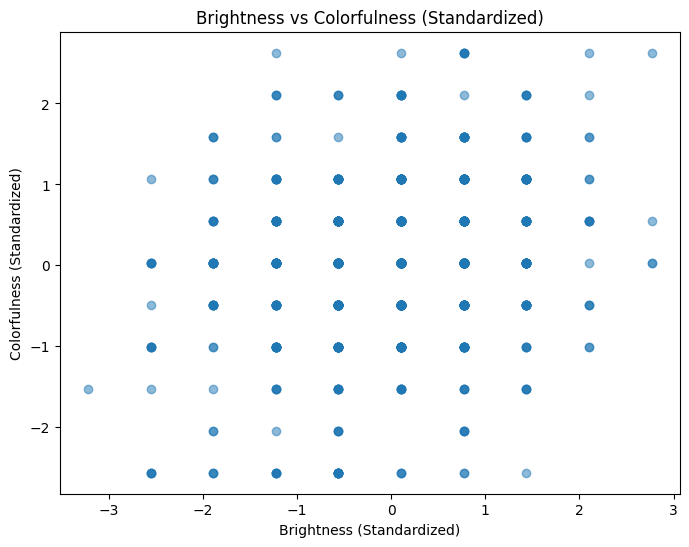

In [14]:
train_df.describe()

# Impute the few missing numeric values with median (preprocessing hasn't run yet)
brightness_col = train_df['brightness'].fillna(train_df['brightness'].median())
colorfulness_col = train_df['colorfulness'].fillna(train_df['colorfulness'].median())
X_numeric = np.column_stack([brightness_col, colorfulness_col])

# Standardize inline
scaler_eda = StandardScaler()
X_numeric_scaled = scaler_eda.fit_transform(X_numeric)

print(f"Correlation between brightness and colorfulness: {np.corrcoef(X_numeric_scaled[:, 0], X_numeric_scaled[:, 1])[0, 1]:.2f}")

# correlate brightness and colorfulness
plt.figure(figsize=(8, 6))
plt.scatter(X_numeric_scaled[:, 0], X_numeric_scaled[:, 1], alpha=0.5)
plt.title('Brightness vs Colorfulness (Standardized)')
plt.xlabel('Brightness (Standardized)')
plt.ylabel('Colorfulness (Standardized)')
plt.show()

### Conclusions from metadata analysis and EDA: 

low correlation between brightness and colorfulness, keep both 
89% of the samples are missing facial expression
We checked the correlation with emotion to see if we can learn anything about it, we can't. 
Looks like there's no null pattern we can manually overcome
Since most of the sample is missing this field, we'll consider to leave this variable out of the analysis.  

In [ ]:
# TODO: rephrase conclusion about the metadata analysis

## Labeling categorial variables - facial_expression and emotion

In [ ]:
# Encode emotion labels inline
le_eda = LabelEncoder()
target = le_eda.fit_transform(train_df['emotion'])
emotion_names_eda = le_eda.classes_

# # Features: One-Hot Encode 'facial_expression' 
# # We use a fresh encoder here so it doesn't conflict with anything else
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# facial_condined = train_df['facial_expression'].fillna('missing').values.reshape(-1, 1)
# facial_encoded = ohe.fit_transform(facial_condined)

# # Convert to dataframe with clear column names for your Feature Analysis [cite: 12]
# facial_expression_df = pd.DataFrame(
#     facial_encoded, 
#     columns=ohe.get_feature_names_out(['facial_expression']), 
#     index=train_df.index
# )


## TFIDF

In [ ]:
# TODO: hyperparameter tuning - how many max features to select per variable?

In [9]:
import ast
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def prefix_text(text, prefix):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    words = [w for w in text.lower().split() if w not in ENGLISH_STOP_WORDS]
    return ' '.join(f"{prefix}_{w}" for w in words)

def prefix_object_list(text, prefix):
    """Handle object column which contains list strings like ['Tree', 'Plant']"""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    try:
        items = ast.literal_eval(text)  # parse ['Tree', 'Plant'] -> ['Tree', 'Plant']
        if isinstance(items, list):
            words = [item.lower().strip() for item in items if item.strip()]
            return ' '.join(f"{prefix}_{w}" for w in words)
    except:
        pass
    # fallback: treat as plain text
    return prefix_text(text, prefix)

train_df['combined_text'] = (
    train_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    train_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    train_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

tfidf_combined = TfidfVectorizer(max_features=80)
combined_matrix = tfidf_combined.fit_transform(train_df['combined_text'])

print(f"Combined TF-IDF matrix shape: {combined_matrix.shape}")
print(f"Sample features: {tfidf_combined.get_feature_names_out()[:20]}")

Combined TF-IDF matrix shape: (800, 80)
Sample features: ['desc_backdrop' 'desc_background' 'desc_black' 'desc_blue'
 'desc_colorful' 'desc_dark' 'desc_features' 'desc_green' 'desc_hair'
 'desc_holding' 'desc_image' 'desc_large' 'desc_man' 'desc_person'
 'desc_red' 'desc_setting' 'desc_shirt' 'desc_shows' 'desc_sky'
 'desc_small']


In [10]:
# present the first 5 rows of combined_matrix
combined_df = pd.DataFrame(combined_matrix[:5].toarray(), columns=tfidf_combined.get_feature_names_out())

In [11]:
print(combined_df.head())
print(combined_df.columns)

   desc_backdrop  desc_background  desc_black  desc_blue  desc_colorful  \
0            0.0              0.0         0.0   0.248431            0.0   
1            0.0              0.0         0.0   0.000000            0.0   
2            0.0              0.0         0.0   0.000000            0.0   
3            0.0              0.0         0.0   0.000000            0.0   
4            0.0              0.0         0.0   0.000000            0.0   

   desc_dark  desc_features  desc_green  desc_hair  desc_holding  ...  \
0        0.0            0.0         0.0   0.000000           0.0  ...   
1        0.0            0.0         0.0   0.445197           0.0  ...   
2        0.0            0.0         0.0   0.415853           0.0  ...   
3        0.0            0.0         0.0   0.000000           0.0  ...   
4        0.0            0.0         0.0   0.000000           0.0  ...   

   feel_setting  feel_thoughts  feel_tranquility  feel_unease  feel_vibrant  \
0           0.0            0.0 

In [ ]:
# Alternatively, we can do separate TF-IDF for each column and then concatenate the features
# 1. Fill NaN values with empty strings to prevent errors
text_columns = ['description', 'viewer_feelings', 'object', 'scene', 'human_action']
train_df[text_columns] = train_df[text_columns].fillna('')

# 2. TF-IDF for long-form text (Description & Viewer Feelings)
# We limit to 200 features because we have 800 training samples
tfidf_desc = TfidfVectorizer(stop_words='english', max_features=200)
tfidf_feel = TfidfVectorizer(stop_words='english', max_features=200)

desc_matrix = tfidf_desc.fit_transform(train_df['description'])
feel_matrix = tfidf_feel.fit_transform(train_df['viewer_feelings'])

# 3. TF-IDF for short metadata tags (Object, Scene, Action)
# These usually have a smaller vocabulary
tfidf_obj = TfidfVectorizer(max_features=100)
tfidf_scene = TfidfVectorizer(max_features=50)
tfidf_action = TfidfVectorizer(max_features=50) # to capture bigrams like "playing guitar"

obj_matrix = tfidf_obj.fit_transform(train_df['object'])
scene_matrix = tfidf_scene.fit_transform(train_df['scene'])
action_matrix = tfidf_action.fit_transform(train_df['human_action'])

In [ ]:
# present the first 5 rows as a dataframe with feature names, of the description, feelings, ogbject, scene, human_action tf-idf matrix separatley

desc_df = pd.DataFrame(desc_matrix[:5].toarray(), columns=tfidf_desc.get_feature_names_out())
feel_df = pd.DataFrame(feel_matrix[:5].toarray(), columns=tfidf_feel.get_feature_names_out())
obj_df = pd.DataFrame(obj_matrix[:5].toarray(), columns=tfidf_obj.get_feature_names_out())
scene_df = pd.DataFrame(scene_matrix[:5].toarray(), columns=tfidf_scene.get_feature_names_out())
action_df = pd.DataFrame(action_matrix[:5].toarray(), columns=tfidf_action.get_feature_names_out())


In [ ]:
# TODO: apply all transformations to the test set as well,
#       using the same encoders and scalers fitted on the training set

## PCA

In [ ]:
svd_combined = TruncatedSVD(n_components=80)
combined_pca = svd_combined.fit_transform(combined_matrix)
print(f"Combined PCA shape: {combined_pca.shape}")

In [ ]:
# We will create 5 separate SVD objects to keep the meanings separate
# n_components are chosen based on the complexity of the source
svd_desc = TruncatedSVD(n_components=40)   # Complex descriptions
svd_feel = TruncatedSVD(n_components=40)   # Complex feelings
svd_obj = TruncatedSVD(n_components=15)    # Objects are simpler tags
svd_scene = TruncatedSVD(n_components=5)    # Scenes are very limited
svd_action = TruncatedSVD(n_components=5)   # Actions are short

# Transform the matrices we created in the previous step
desc_pca = svd_desc.fit_transform(desc_matrix)
feel_pca = svd_feel.fit_transform(feel_matrix)
obj_pca = svd_obj.fit_transform(obj_matrix)
scene_pca = svd_scene.fit_transform(scene_matrix)
action_pca = svd_action.fit_transform(action_matrix)

print(f"Total Text/Tag Features: {desc_pca.shape[1] + feel_pca.shape[1] + obj_pca.shape[1] + scene_pca.shape[1] + action_pca.shape[1]}")
# Total should be around 105 features

In [ ]:

# --- PLOT 1: Explained Variance Ratio (Scree Plot) ---
def plot_variance(pca_model, title=''):
    indv_var = pca_model.explained_variance_ratio_
    cum_var = np.cumsum(indv_var)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(indv_var) + 1), indv_var, marker='o', color='purple', label='Individual Component', linewidth=2)
    plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='orange', label='Cumulative', linewidth=2)
    plt.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7, label='85% threshold')

    plt.title(f"Explained Variance Ratio - {title}")
    plt.xlabel("Number of Components")
    plt.ylabel("Explained Variance Ratio")
    plt.xticks(range(1, len(indv_var) + 1))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  {title}: {cum_var[-1]:.1%} total variance explained with {len(indv_var)} components")


# --- PLOT 2: 3D Projection ---
def plot_3d_pca(X_pca, labels, emotion_names, title=''):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    cmap = plt.cm.get_cmap('tab10', len(emotion_names))
    for i, name in enumerate(emotion_names):
        mask = labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                   c=[cmap(i)], label=name, alpha=0.6, s=20)

    ax.set_title(f"3D PCA Projection - {title}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.view_init(elev=10, azim=-95)
    ax.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


# --- PLOT 3: 2D Projection ---
def plot_2d_pca(X_pca, labels, emotion_names, title=''):
    plt.figure(figsize=(8, 6))

    cmap = plt.cm.get_cmap('tab10', len(emotion_names))
    for i, name in enumerate(emotion_names):
        mask = labels == i
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cmap(i)], label=name, alpha=0.8, s=20)

    plt.title(f"2D PCA Projection - {title}")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


# --- Check variance explained for all SVD models ---
print("=== Variance Explained Summary ===")
for svd_model, name in [
    # (svd_desc,   'Description (40 components)'),
    # (svd_feel,   'Viewer Feelings (40 components)'),
    # (svd_obj,    'Object (15 components)'),
    # (svd_scene,  'Scene (5 components)'),
    # (svd_action, 'Action (5 components)'),
    (svd_combined, 'All Text Combined (80 components)')
]:
    plot_variance(svd_model, title=name)


In [ ]:
## PCA on All Metadata text Features Combined
# --- 2D and 3D scatter colored by emotion ---
y = target
emotion_names = le_eda.classes_
plot_2d_pca(combined_pca, y, emotion_names, title='All Text Metadata Features')
plot_3d_pca(combined_pca, y, emotion_names, title='All Text Metadata Features')

In [ ]:
# these are the PCA results after excluding facial exression, scene and human_action, which had a lot of missing values and didn't add much variance 
# TODO: explain this change and the rationale behind it, and how it affected the PCA results

## K-MEANS / K-MODES

In [ ]:
# TODO: debug the k-means clustering and ARI calculation, and add visualizations of the clusters in PCA space

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# K-Means with k=8 (one cluster per emotion)
kmeans_numeric = KMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels_numeric = kmeans_numeric.fit_predict(X_numeric_scaled)

ari_numeric = adjusted_rand_score(target, cluster_labels_numeric)
print(f"ARI (brightness + colorfulness only): {ari_numeric:.3f}")
print("ARI=0 → no better than random  |  ARI=1 → perfect alignment with emotion labels")

# Side-by-side: true emotion labels vs K-Means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', 8)

for i, name in enumerate(emotion_names_eda):
    mask = target == i
    axes[0].scatter(X_numeric_scaled[mask, 0], X_numeric_scaled[mask, 1],
                    c=[cmap(i)], label=name, alpha=0.7, s=25)
axes[0].set_title('True Emotion Labels')
axes[0].set_xlabel('Brightness (standardized)')
axes[0].set_ylabel('Colorfulness (standardized)')
axes[0].legend(title='Emotion', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(8):
    mask = cluster_labels_numeric == i
    axes[1].scatter(X_numeric_scaled[mask, 0], X_numeric_scaled[mask, 1],
                    c=[cmap(i)], label=f'Cluster {i}', alpha=0.7, s=25)
axes[1].set_title(f'K-Means Clusters (k=8)  —  ARI = {ari_numeric:.3f}')
axes[1].set_xlabel('Brightness (standardized)')
axes[1].set_ylabel('Colorfulness (standardized)')
axes[1].legend(title='Cluster', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('EDA Clustering — Numeric Features Only (brightness & colorfulness)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Combine all processed metadata features: numeric + SVD-reduced text
X_all = np.hstack([
    train_df[['standardized_brightness', 'standardized_colorfulness']].values,  # 2 features
    combined_pca,                                                                 # 80 SVD components
])
print(f"Feature matrix shape: {X_all.shape}")

# K-Means with k=8 (one cluster per emotion)
kmeans_all = KMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels_all = kmeans_all.fit_predict(X_all)

ari_all = adjusted_rand_score(y, cluster_labels_all)
print(f"ARI (all metadata features): {ari_all:.3f}")
print("ARI=0 → no better than random  |  ARI=1 → perfect alignment with emotion labels")

# Side-by-side scatter using the first 2 SVD components for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', 8)

for i, name in enumerate(emotion_names):
    mask = y == i
    axes[0].scatter(combined_pca[mask, 0], combined_pca[mask, 1],
                    c=[cmap(i)], label=name, alpha=0.7, s=25)
axes[0].set_title('True Emotion Labels')
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')
axes[0].legend(title='Emotion', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(8):
    mask = cluster_labels_all == i
    axes[1].scatter(combined_pca[mask, 0], combined_pca[mask, 1],
                    c=[cmap(i)], label=f'Cluster {i}', alpha=0.7, s=25)
axes[1].set_title(f'K-Means Clusters (k=8)  —  ARI = {ari_all:.3f}')
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')
axes[1].legend(title='Cluster', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('EDA Clustering — All Metadata Features (brightness, colorfulness, text SVD)', fontsize=13)
plt.tight_layout()
plt.show()

# Which emotion dominates each cluster?
cluster_emotion_df = pd.DataFrame({'cluster': cluster_labels_all, 'emotion': train_df['emotion'].values})
dominant = cluster_emotion_df.groupby('cluster')['emotion'].agg(lambda x: x.value_counts().index[0])
counts   = cluster_emotion_df.groupby('cluster')['emotion'].agg(lambda x: x.value_counts().iloc[0])
summary  = pd.DataFrame({'dominant_emotion': dominant, 'count_in_cluster': counts,
                          'cluster_size': cluster_emotion_df.groupby('cluster').size()})
summary['purity'] = summary['count_in_cluster'] / summary['cluster_size']
print("\nCluster summary (dominant emotion & purity):")
print(summary.to_string())


# Modeling 

> Note to self: We need to compare at least 2-3 models (e.g., multinominal Logistic Regression with L1, Random Forest with feature importance using gini, maybe gradient boosting) using cross-validation on the training set, then evaluate the winner on the test set.

## 1. Tabular model
Steps: 
1. Choose 2-3 potential models
2. Use cross validation on the training set - use GridSearchCV to do hyperparameter tunning
3. Assess feature importance
4. Evaluate performance of best model on the test set + interpret (maybe compare train and test performance)

In [ ]:
# Variables to include:
# - brightness
# - colorfulness
# - features from the text columns (after TF-IDF - description, viewer_feelings, object)

In [36]:
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# ── 1. Assemble feature matrix ──────────────────────────────────────────────
X_train = hstack([combined_matrix, csr_matrix(X_numeric_scaled)])
le = le_eda
y_train = target
emotion_names = le_eda.classes_
print(f"Feature matrix shape: {X_train.shape}")

# ── 2. Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression (L1)': LogisticRegression(
        penalty='l1', solver='saga', max_iter=1000, random_state=42
    ),
    'Logistic Regression (L2)': LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

# ── 3. Cross-validation ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    # Accuracy
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Precision and Recall (macro = equal weight per class)
    precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision_macro')
    recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall_macro')
    
    # AUC - needs probability estimates (roc_auc_ovr = one vs rest for multiclass)
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc_ovr')
    
    results[name] = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'auc': auc,
    }
    print(f"\n{name}")
    for metric, scores in results[name].items():
        print(f"  {metric:22s} mean={scores.mean():.3f}  std={scores.std():.3f}")

Feature matrix shape: (800, 82)

Logistic Regression (L1)
  accuracy               mean=0.584  std=0.035
  precision              mean=0.590  std=0.040
  recall                 mean=0.585  std=0.035
  auc                    mean=0.904  std=0.013

Logistic Regression (L2)
  accuracy               mean=0.588  std=0.031
  precision              mean=0.591  std=0.034
  recall                 mean=0.588  std=0.031
  auc                    mean=0.912  std=0.009

Random Forest
  accuracy               mean=0.576  std=0.031
  precision              mean=0.583  std=0.030
  recall                 mean=0.577  std=0.031
  auc                    mean=0.900  std=0.013

Gradient Boosting
  accuracy               mean=0.560  std=0.039
  precision              mean=0.564  std=0.039
  recall                 mean=0.561  std=0.040
  auc                    mean=0.883  std=0.015


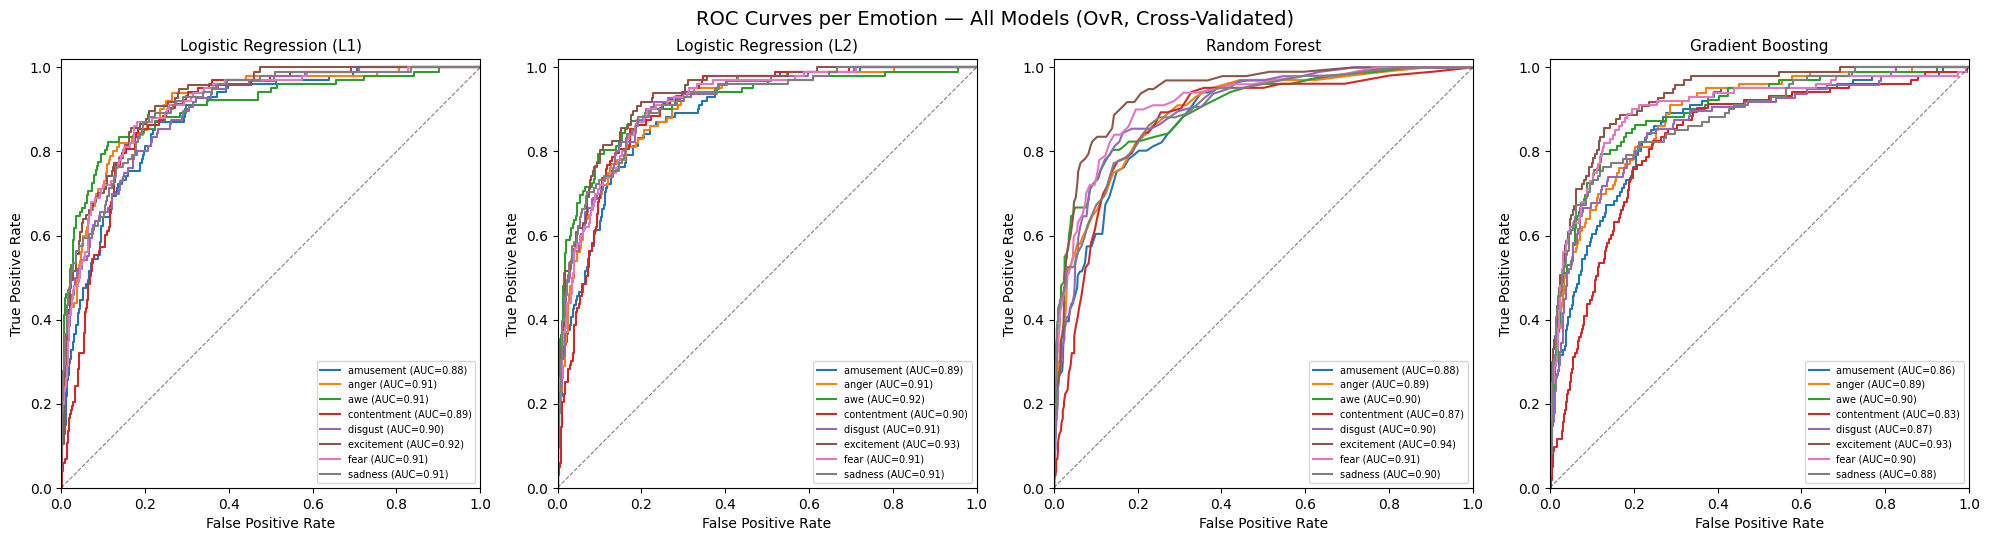

In [38]:
# plot ROC curves for each model -
# one panel for each model
# represent each emotion class as a separate curve in the panel, and include a legend to identify which curve corresponds to which emotion class
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict

# Binarize labels for OvR ROC (shape: n_samples x n_classes)
y_bin = label_binarize(y_train, classes=range(len(emotion_names)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    # Get probability estimates via cross-validation
    y_prob = cross_val_predict(
        model, X_train, y_train, cv=cv, method='predict_proba'
    )
    # y_prob shape: (n_samples, n_classes)
    
    # Plot one ROC curve per emotion
    for i, emotion in enumerate(emotion_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f"{emotion} (AUC={roc_auc:.2f})")
    
    # Random chance line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# Hide the last empty panel if models < 8
for j in range(len(models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves per Emotion — All Models (OvR, Cross-Validated)', fontsize=14)
plt.tight_layout()
plt.show()

                          accuracy  precision  recall    auc
Logistic Regression (L1)     0.584      0.590   0.585  0.904
Logistic Regression (L2)     0.588      0.591   0.588  0.912
Random Forest                0.576      0.583   0.577  0.900
Gradient Boosting            0.560      0.564   0.561  0.883


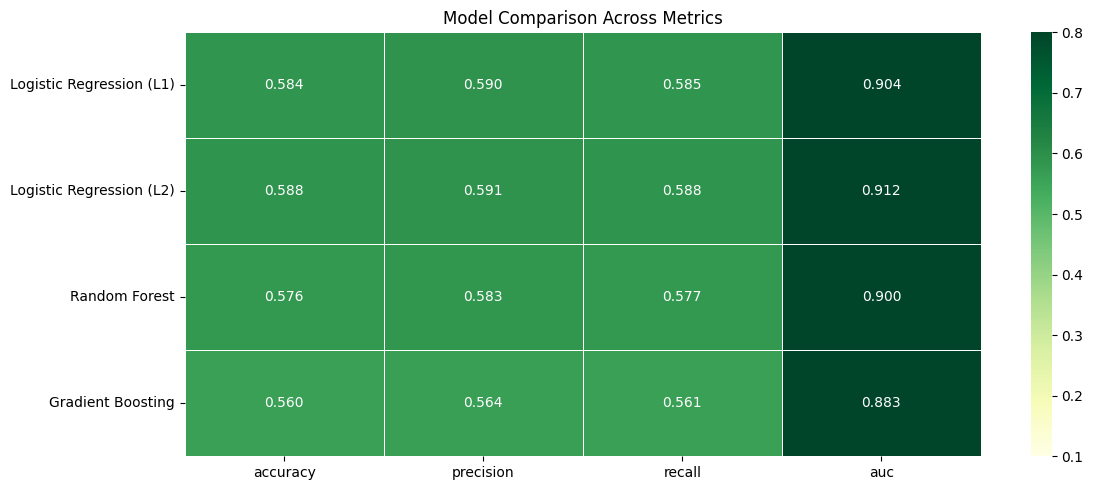

In [37]:
summary = pd.DataFrame({
    name: {metric: scores.mean() for metric, scores in metrics.items()}
    for name, metrics in results.items()
}).T.round(3)

print(summary)

plt.figure(figsize=(12, 5))
sns.heatmap(summary, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, vmin=0.1, vmax=0.8)
plt.title('Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

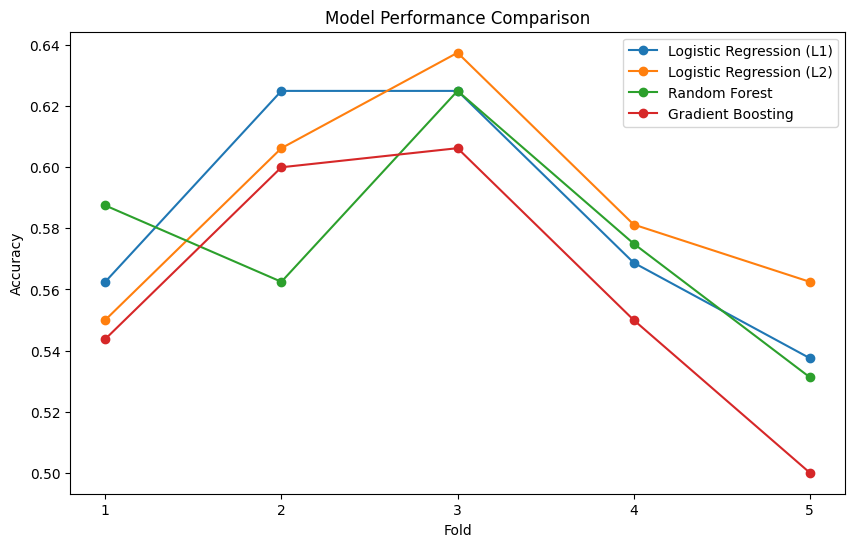

In [33]:
# plot the results as score per fold for each model (colorcode the models and add a legend)
plt.figure(figsize=(10, 6))
for name, scores in results.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)
plt.xlabel('Fold')
plt.xticks(range(1, 6))
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

Step 1 — GridSearchCV on the best model

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV accuracy: 0.588


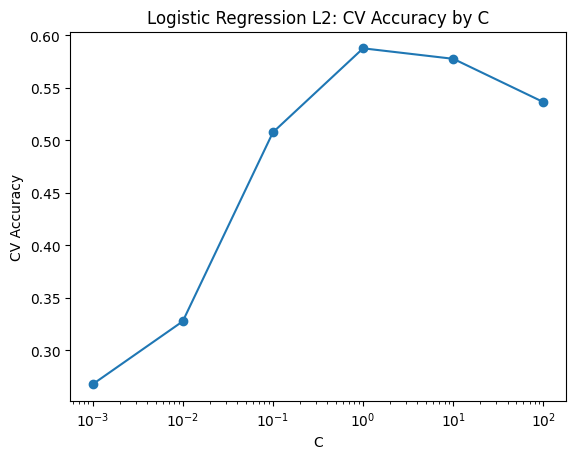

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best C: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

# See how all C values performed
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.plot(param_grid['C'], cv_results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('CV Accuracy')
plt.title('Logistic Regression L2: CV Accuracy by C')
plt.show()

Step 2 — Feature importance (differs by model):

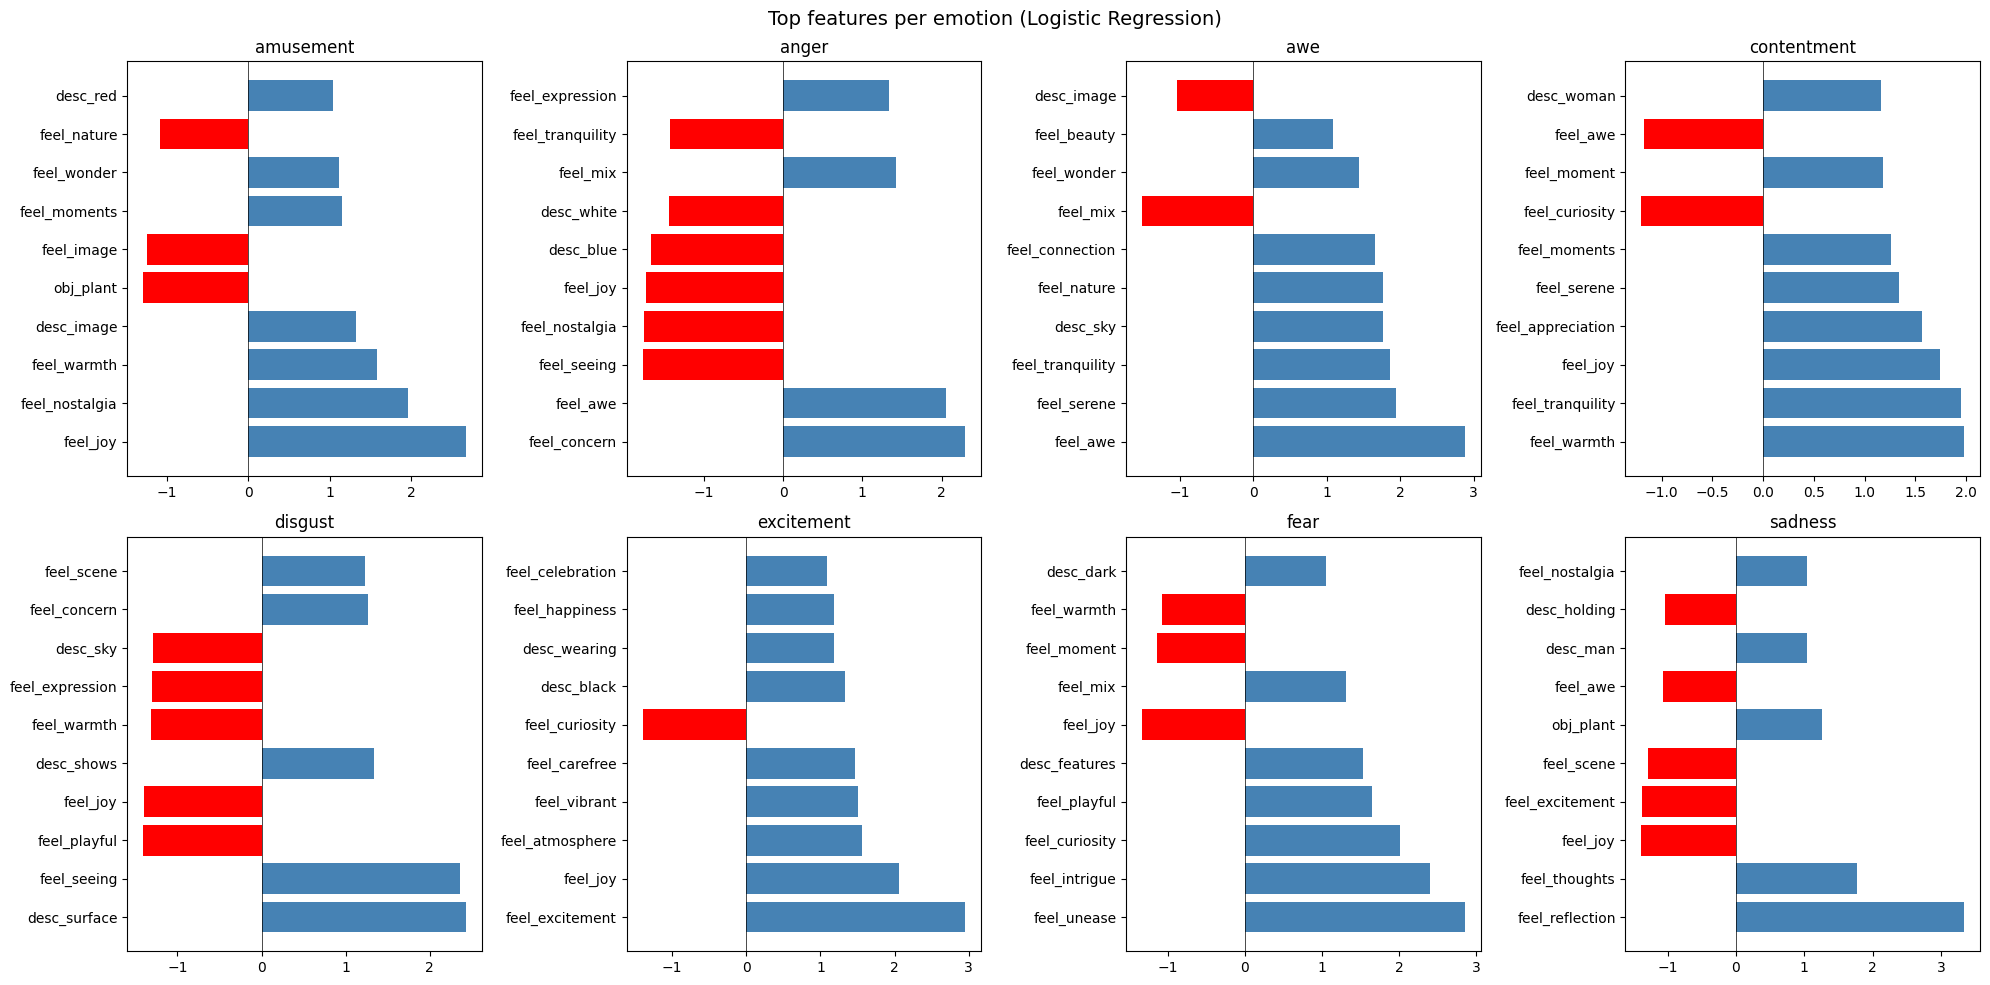

In [26]:
import matplotlib.pyplot as plt

# Get feature names (TF-IDF + numeric)
feature_names = list(tfidf_combined.get_feature_names_out()) + ['brightness', 'colorfulness']

# ── For Logistic Regression ──────────────────────────────────────────────────
# coef_ shape is (n_classes, n_features) - one row per emotion
coef_df = pd.DataFrame(
    best_model.coef_,
    index=emotion_names,
    columns=feature_names
)

# Plot top N features per emotion
n_top = 10
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotion_names):
    top_features = coef_df.loc[emotion].abs().nlargest(n_top)
    colors = ['red' if coef_df.loc[emotion, f] < 0 else 'steelblue' for f in top_features.index]
    axes[i].barh(top_features.index, coef_df.loc[emotion, top_features.index], color=colors)
    axes[i].set_title(emotion)
    axes[i].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Top features per emotion (Logistic Regression)', fontsize=14)
plt.tight_layout()
plt.show()

# ── For Random Forest (if that wins instead) ─────────────────────────────────
# importances = best_model.feature_importances_
# importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
# importance_df.sort_values('importance', ascending=False).head(20)


--- amusement ---


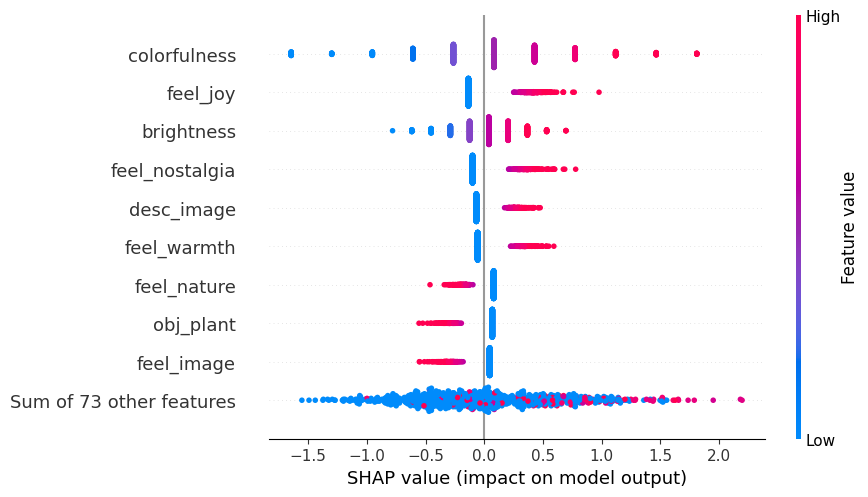


--- anger ---


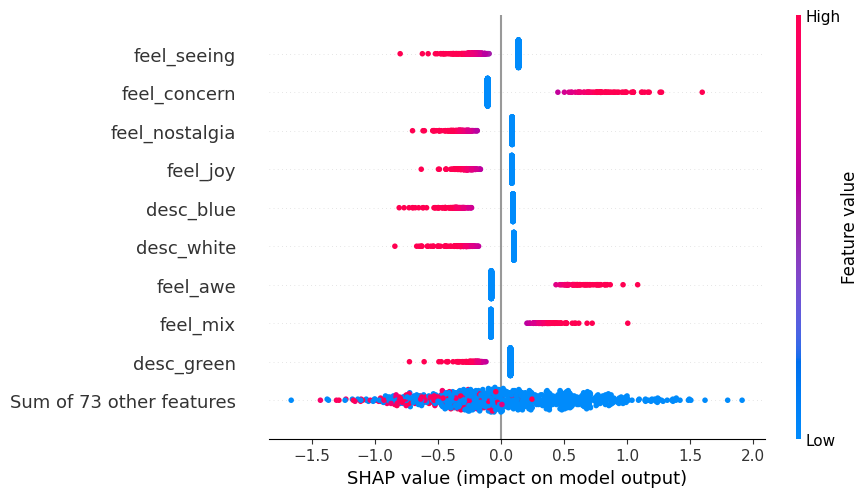


--- awe ---


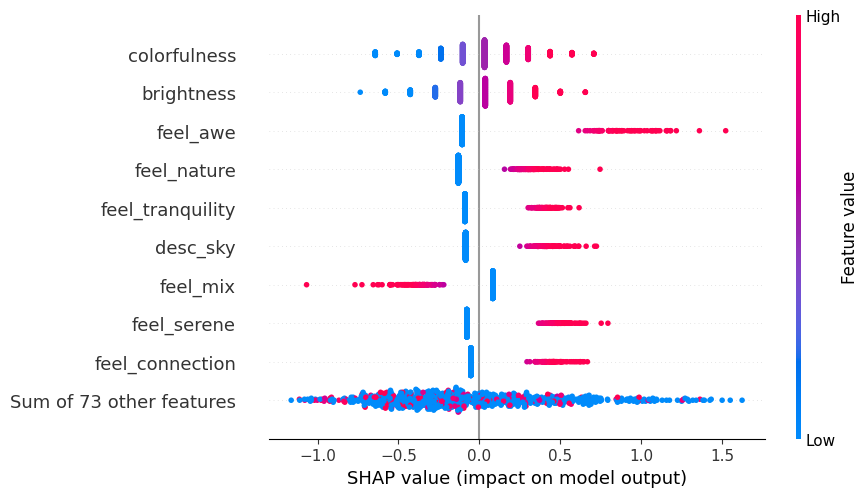


--- contentment ---


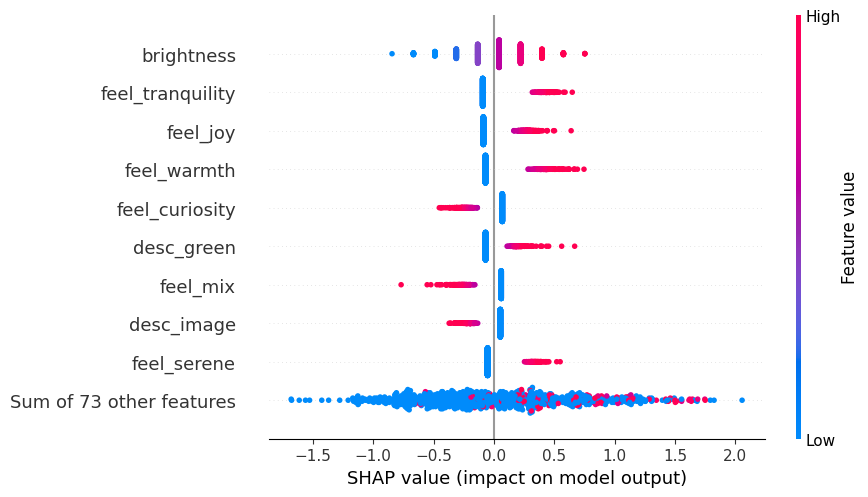


--- disgust ---


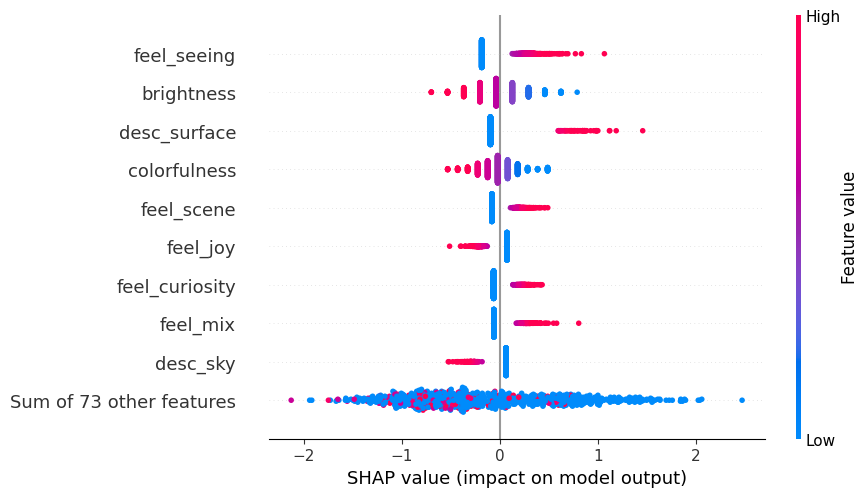


--- excitement ---


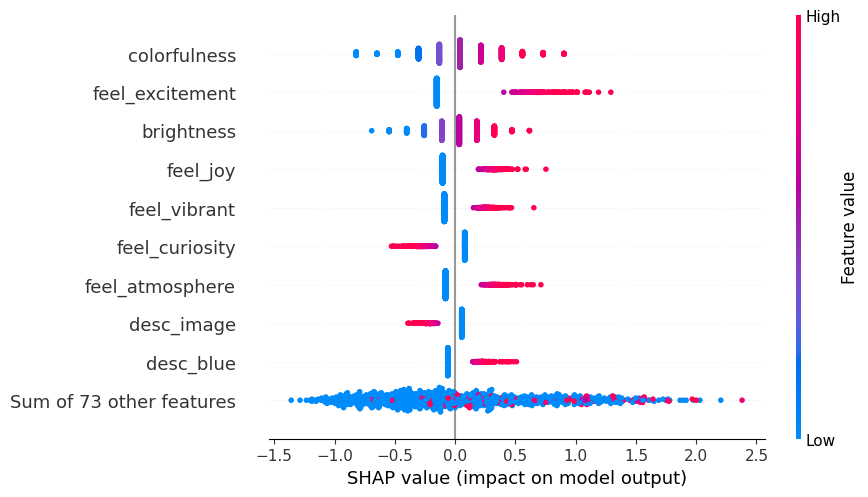


--- fear ---


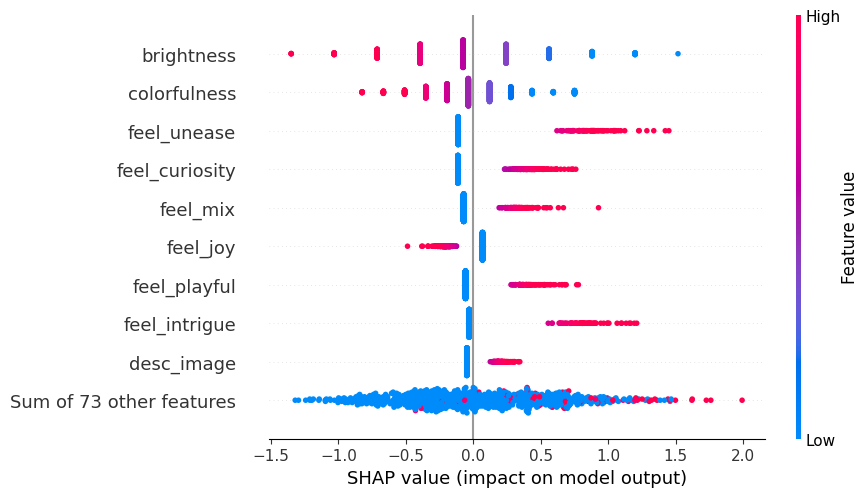


--- sadness ---


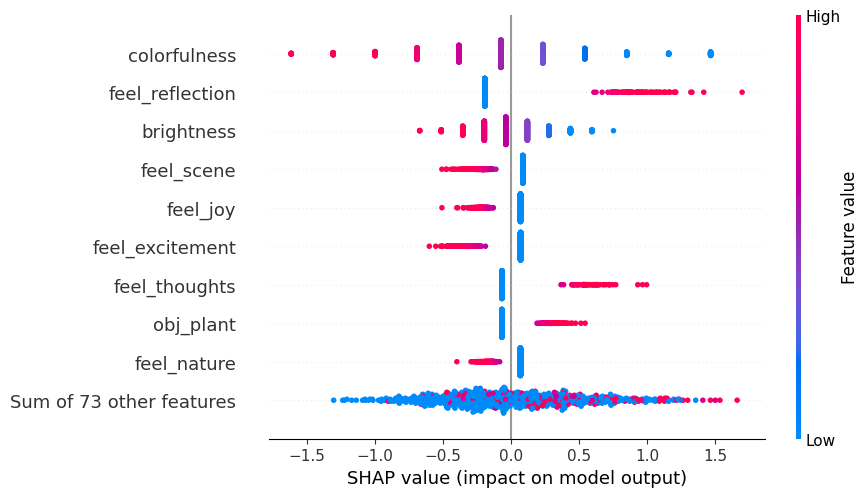

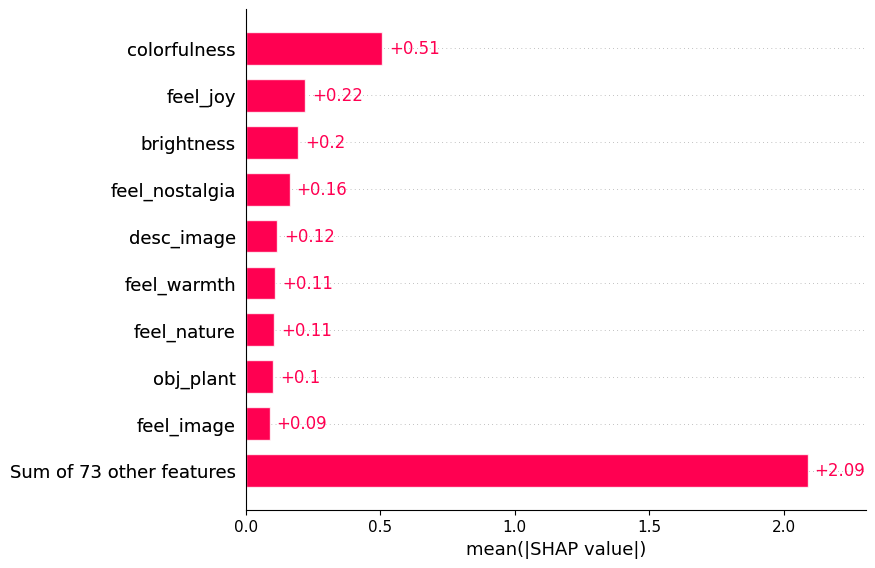

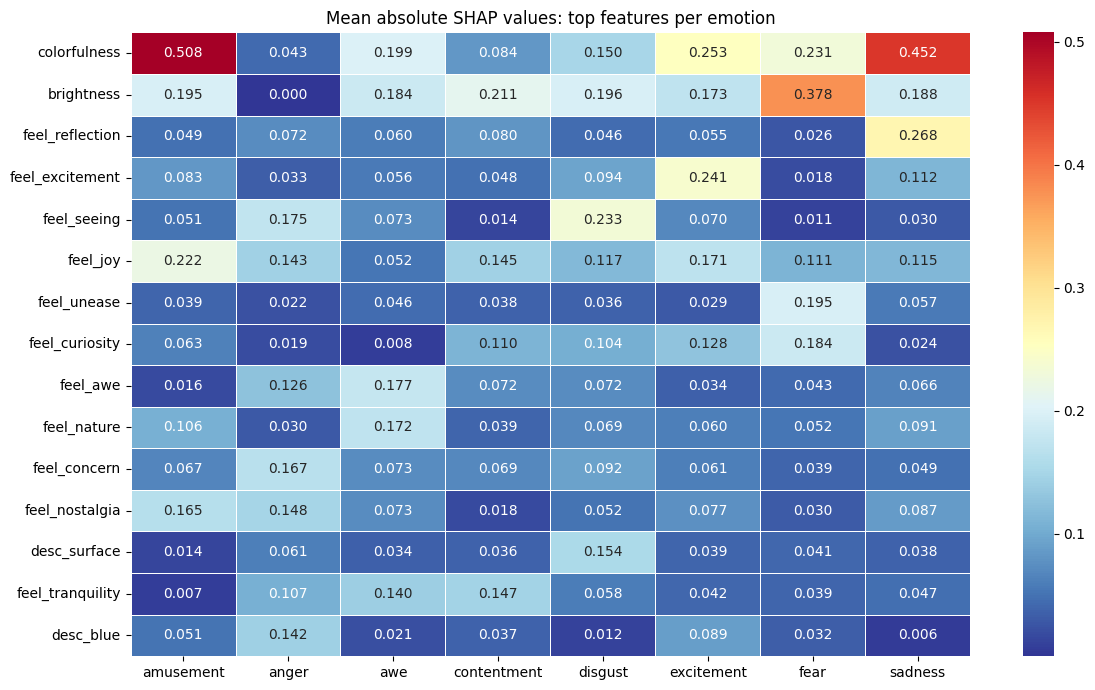

In [30]:
import shap

# Convert to DataFrame with feature names BEFORE passing to SHAP
X_train_dense = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

explainer = shap.LinearExplainer(best_model, X_train_dense)
shap_values = explainer(X_train_dense)

# Now plots will show actual feature names like desc_woman, feel_happy etc.
for i, emotion in enumerate(emotion_names):
    print(f"\n--- {emotion} ---")
    shap.plots.beeswarm(shap_values[:, :, i], max_display=10, show=True)
    
# ── Plot 2: Bar - mean absolute SHAP per feature (like classic feature importance)
shap.plots.bar(shap_values[:, :, 0])

# ── Plot 3: Heatmap across all emotions - good for presentation ──────────────
# Mean absolute SHAP per feature per emotion
mean_shap = np.abs(shap_values.values).mean(axis=0)  # shape (82, 8)
shap_df = pd.DataFrame(mean_shap, index=feature_names, columns=emotion_names)

# Plot top 15 features overall
top_features = shap_df.max(axis=1).nlargest(15).index
plt.figure(figsize=(12, 7))
import seaborn as sns
sns.heatmap(
    shap_df.loc[top_features],
    cmap='RdYlBu_r',
    annot=True, fmt='.3f',
    linewidths=0.5
)
plt.title('Mean absolute SHAP values: top features per emotion')
plt.tight_layout()
plt.show()

             feature  mean_abs_shap
0       colorfulness       0.239882
1         brightness       0.190646
2           feel_joy       0.134301
3    feel_excitement       0.085618
4           feel_mix       0.084688
5         desc_image       0.082846
6    feel_reflection       0.081922
7        feel_seeing       0.081895
8     feel_nostalgia       0.081166
9     feel_curiosity       0.080050
10       feel_nature       0.077495
11      feel_concern       0.077035
12          feel_awe       0.075898
13  feel_tranquility       0.073175
14       feel_warmth       0.065898
15        feel_scene       0.059012
16       feel_unease       0.057781
17       feel_serene       0.055367
18          desc_sky       0.054557
19      desc_surface       0.052017


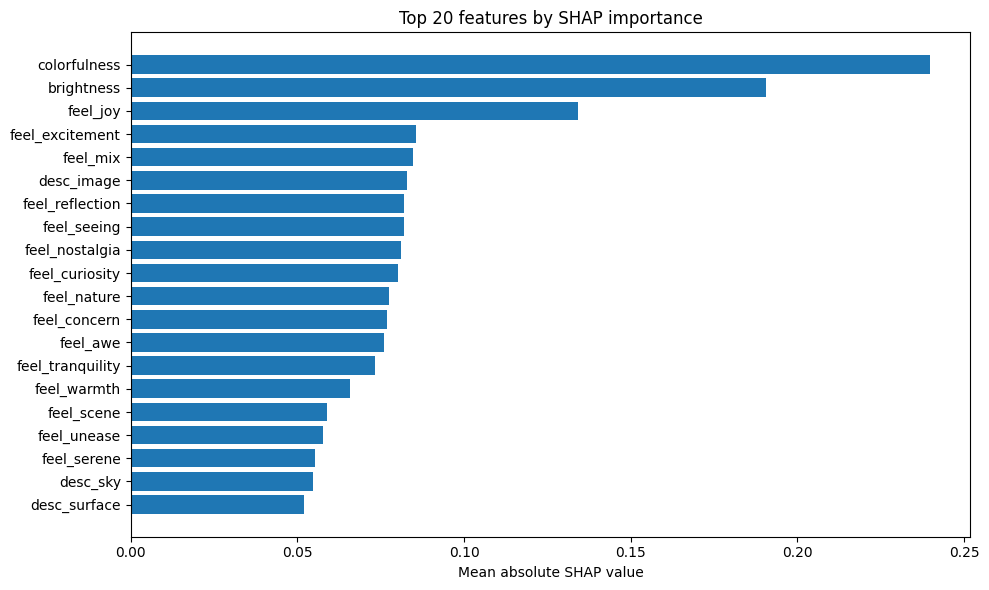

Top  10 features — AUC mean=0.838  std=0.019
Top  20 features — AUC mean=0.891  std=0.015
Top  30 features — AUC mean=0.902  std=0.012
Top  40 features — AUC mean=0.908  std=0.011
Top  50 features — AUC mean=0.912  std=0.009
Top  60 features — AUC mean=0.914  std=0.008
Top  82 features — AUC mean=0.912  std=0.009


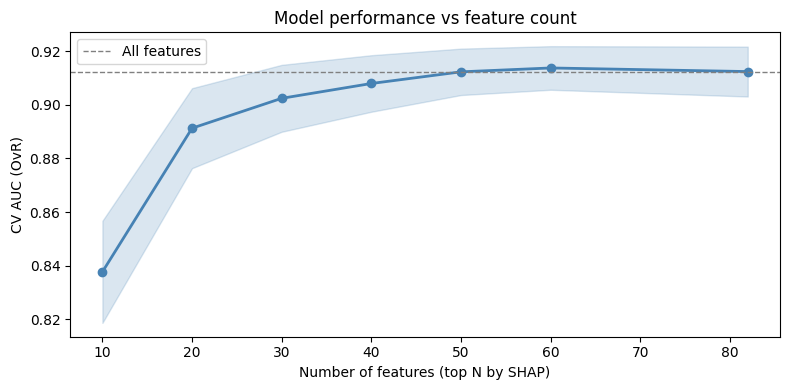

Best cutoff: top 60 features
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV AUC: 0.914


In [39]:
# ── 1. Get mean absolute SHAP per feature (across all emotions) ──────────────
# shap_values.values shape: (n_samples, n_features, n_classes)
mean_shap_per_feature = np.abs(shap_values.values).mean(axis=(0, 2))  
# average over samples AND classes → shape: (n_features,)

# Create a ranked dataframe
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_shap_per_feature
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance_df.head(20))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['feature'][:20][::-1], 
         shap_importance_df['mean_abs_shap'][:20][::-1])
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 features by SHAP importance')
plt.tight_layout()
plt.show()

# ── 2. Try different feature cutoffs using CV ────────────────────────────────
# Instead of arbitrarily picking top-N, test several thresholds

cutoffs = [10, 20, 30, 40, 50, 60, 82]  # 82 = all features
cutoff_results = {}

for n in cutoffs:
    # Select top N feature indices
    top_n_features = shap_importance_df['feature'][:n].tolist()
    top_n_idx = [feature_names.index(f) for f in top_n_features]
    
    # Subset the feature matrix
    X_subset = X_train_dense.iloc[:, top_n_idx]
    
    # CV with best model
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_subset, y_train, cv=cv, scoring='roc_auc_ovr'
    )
    cutoff_results[n] = scores
    print(f"Top {n:3d} features — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── 3. Plot performance vs number of features ────────────────────────────────
means = [cutoff_results[n].mean() for n in cutoffs]
stds = [cutoff_results[n].std() for n in cutoffs]

plt.figure(figsize=(8, 4))
plt.plot(cutoffs, means, marker='o', color='steelblue', linewidth=2)
plt.fill_between(cutoffs, 
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='steelblue')
plt.axhline(means[-1], color='gray', linestyle='--', linewidth=1, label='All features')
plt.xlabel('Number of features (top N by SHAP)')
plt.ylabel('CV AUC (OvR)')
plt.title('Model performance vs feature count')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Select best cutoff and retrain final model ────────────────────────────
best_n = cutoffs[np.argmax(means)]
print(f"Best cutoff: top {best_n} features")

top_features_final = shap_importance_df['feature'][:best_n].tolist()
top_idx_final = [feature_names.index(f) for f in top_features_final]

X_train_final = X_train_dense.iloc[:, top_idx_final]

# Retrain with GridSearchCV on reduced feature set
grid_search_final = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc_ovr', verbose=1
)
grid_search_final.fit(X_train_final, y_train)
best_model_final = grid_search_final.best_estimator_

print(f"Best C: {grid_search_final.best_params_}")
print(f"Best CV AUC: {grid_search_final.best_score_:.3f}")

Step 3 — Evaluate on test set:

In [ ]:
# Apply the SAME preprocessing to test_df
test_df[text_columns] = test_df[text_columns].fillna('')
test_df['combined_text'] = (
    test_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    test_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    test_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

# Use transform (NOT fit_transform) on test data
test_tfidf = tfidf_combined.transform(test_df['combined_text'])
test_numeric = scaler.transform(test_df[['brightness', 'colorfulness']].fillna(
    train_df[['brightness', 'colorfulness']].median()
))
X_test = hstack([test_tfidf, csr_matrix(test_numeric)])
y_test = le_eda.transform(test_df['emotion'])

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=emotion_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

In [ ]:
# TODO: after selecting the best model, fit it on the entire training set and evaluate on the test set, 
#       and inverse transform the predicted labels to the original emotion names for interpretation
predicted_emotions = le_eda.inverse_transform(model.predict(X_test))

## 2. Embedding model

### Applying PCA on the embedded variables

In [ ]:
# > hint: use Exercise V LassoCV and LogisticRegressionCV for feature selection and modeling